```markdown
# Spam Message Classification using Numeric Features

## Project Overview
This notebook demonstrates a preliminary analysis for classifying messages as 'spam' or 'ham' (not spam) based on a set of numeric features extracted from the message content. The goal is to understand the characteristics of spam and ham messages and to prepare the data for further machine learning model development.

## Dataset
The dataset used in this analysis is `numeric_spam_dataset.csv`, which contains the following numerical features for each message:
- `message_length`: Length of the message.
- `word_count`: Number of words in the message.
- `digit_count`: Number of digits in the message.
- `uppercase_count`: Number of uppercase characters in the message.
- `special_char_count`: Number of special characters in the message.
- `exclamation_count`: Number of exclamation marks in the message.
- `question_count`: Number of question marks in the message.
- `url_count`: Number of URLs in the message.
- `currency_count`: Number of currency symbols in the message.
- `spam`: Target variable (0 for ham, 1 for spam).

## Data Preprocessing Steps
1.  **Loading Data**: The dataset is loaded into a Pandas DataFrame.
2.  **Dataset Size**: Checked the number of rows and columns.
3.  **Missing Values**: Verified for any missing values in the dataset. (None found).
4.  **Duplicate Values**: Identified and removed duplicate rows to ensure data integrity and avoid bias in analysis and modeling.
5.  **Spam Distribution**: Analyzed the distribution of 'spam' vs. 'ham' messages using `value_counts()` and visualized with a bar chart.

## Outlier Detection and Removal
Outliers in numerical features were identified and handled using the Z-score method.
1.  **Initial Outlier Detection**: Z-scores were calculated for each numeric feature, and observations with an absolute Z-score greater than 3 were identified as outliers.
2.  **Visualization of Outliers (Before Removal)**: Bar plots were generated to show the count of outliers in each feature before removal, and scatter plots for each feature were used to visually inspect their distribution.
3.  **Outlier Removal**: Rows containing at least one outlier (based on the Z-score criterion) were removed from the dataset, creating a `df_clean` DataFrame.
4.  **Verification of Removal**: The new dataset size and the number of removed rows were reported.
5.  **Visualization of Outliers (After Removal)**: Bar plots and scatter plots for each feature were re-generated using the `df_clean` DataFrame to confirm the effect of outlier removal.

## Next Steps
-   Further exploratory data analysis on the cleaned dataset.
-   Feature scaling.
-   Training and evaluation of machine learning models for spam classification.
-   Hyperparameter tuning and model optimization.
```

In [6]:
import pandas as pd

df = pd.read_csv("/content/numeric_spam_dataset.csv")

print(df.head(2))
print(df.tail(3))

   message_length  word_count  digit_count  uppercase_count  \
0             111          20            0                3   
1              29           6            0                2   

   special_char_count  exclamation_count  question_count  url_count  \
0                   9                  0               0          0   
1                   6                  0               0          0   

   currency_count  spam  
0               0     0  
1               0     0  
      message_length  word_count  digit_count  uppercase_count  \
5569              57          10            0                2   
5570             125          26            0                2   
5571              26           6            0                2   

      special_char_count  exclamation_count  question_count  url_count  \
5569                   7                  0               1          0   
5570                   1                  0               0          0   
5571                   1       

DATASET SIZE

In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5572
Number of columns: 10


MISSING VALUES

In [ ]:
df.isnull().sum()

,0
message_length,0
word_count,0
digit_count,0
uppercase_count,0
special_char_count,0
exclamation_count,0
question_count,0
url_count,0
currency_count,0
spam,0


DUPLICATE VALUES

In [8]:
print("Number of duplicate rows:",
      df.duplicated().sum())

Number of duplicate rows: 1138


REMOVING DUPLICATE VALUES

In [9]:
df = df.drop_duplicates()
print(df)

      message_length  word_count  digit_count  uppercase_count  \
0                111          20            0                3   
1                 29           6            0                2   
2                155          28           25               10   
3                 49          11            0                2   
4                 61          13            0                2   
...              ...         ...          ...              ...   
5566             147          28            5               14   
5567             161          30           21               10   
5568              37           8            0                2   
5569              57          10            0                2   
5570             125          26            0                2   

      special_char_count  exclamation_count  question_count  url_count  \
0                      9                  0               0          0   
1                      6                  0               0

CHECK SPAM MSG

In [10]:
print(df["spam"].value_counts())

spam
0    3814
1     620
Name: count, dtype: int64


BARCHART

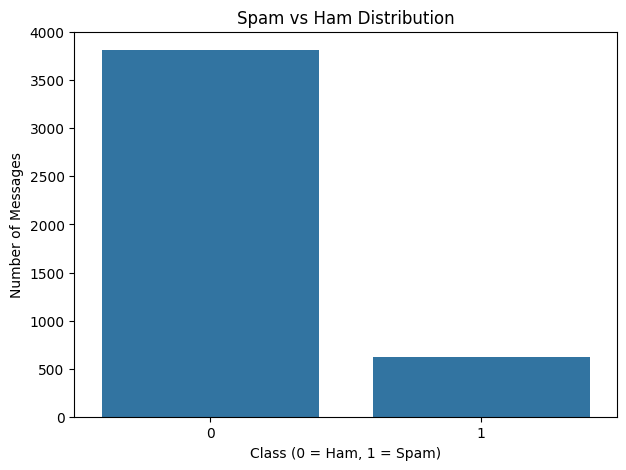

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="spam"
)

plt.title("Spam vs Ham Distribution")
plt.xlabel("Class (0 = Ham, 1 = Spam)")
plt.ylabel("Number of Messages")

plt.show()
plt.show()

DTECTION OF OUTLIERS


In [12]:
from scipy.stats import zscore
numeric_features = [
    "message_length",
    "word_count",
    "digit_count",
    "uppercase_count",
    "special_char_count",
    "exclamation_count",
    "question_count",
    "url_count",
    "currency_count"
]
z_scores = df[numeric_features].apply(zscore)
outliers = (z_scores.abs() > 3)
print(outliers.sum())

message_length         53
word_count             52
digit_count           184
uppercase_count        78
special_char_count     57
exclamation_count      79
question_count         62
url_count              90
currency_count        224
dtype: int64


VISUALIZATION OF WITHOUT REMOVAL OF OUTLIERS

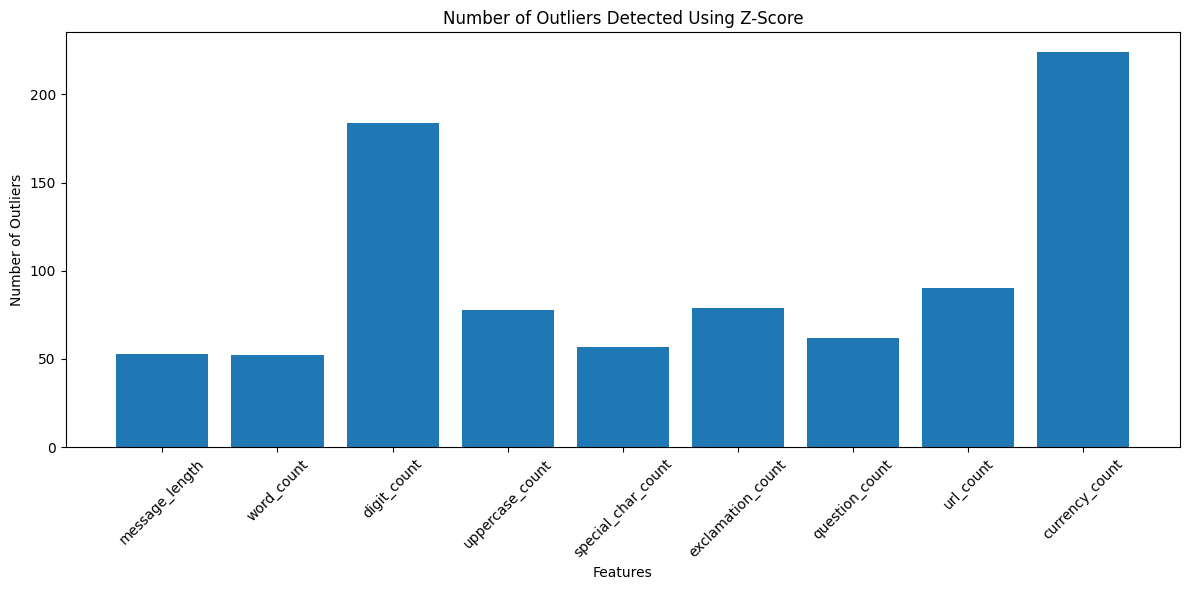

In [13]:
plt.figure(figsize=(12, 6))

plt.bar(
    numeric_features,
    outliers.sum().values
)

plt.title("Number of Outliers Detected Using Z-Score")
plt.xlabel("Features")
plt.ylabel("Number of Outliers")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

BOX PLOTS

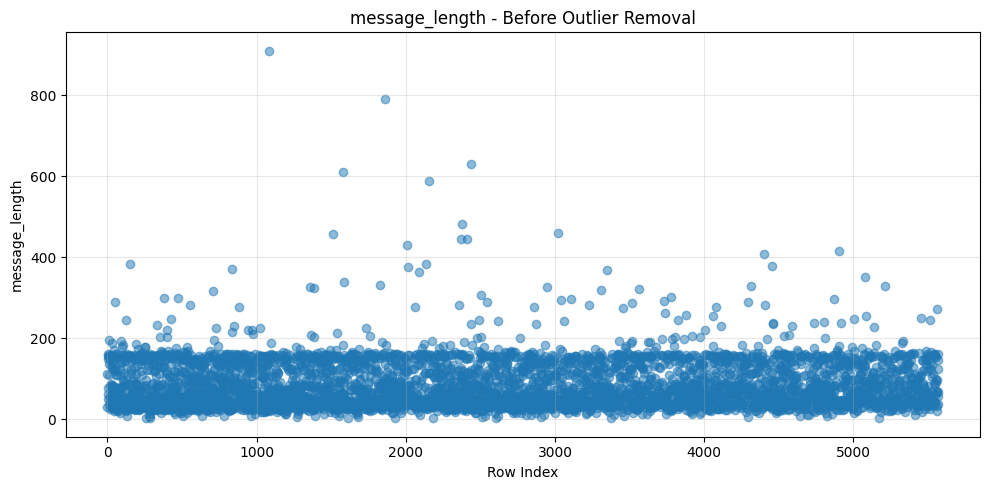

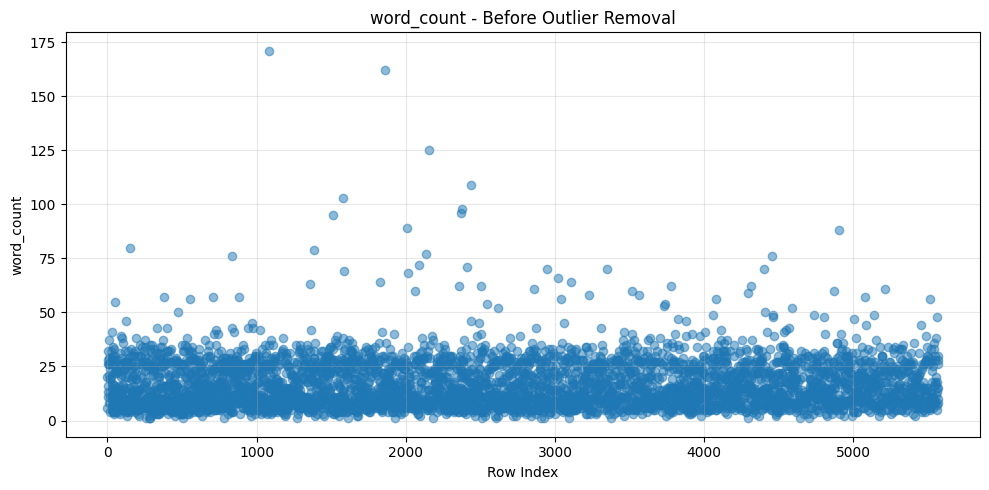

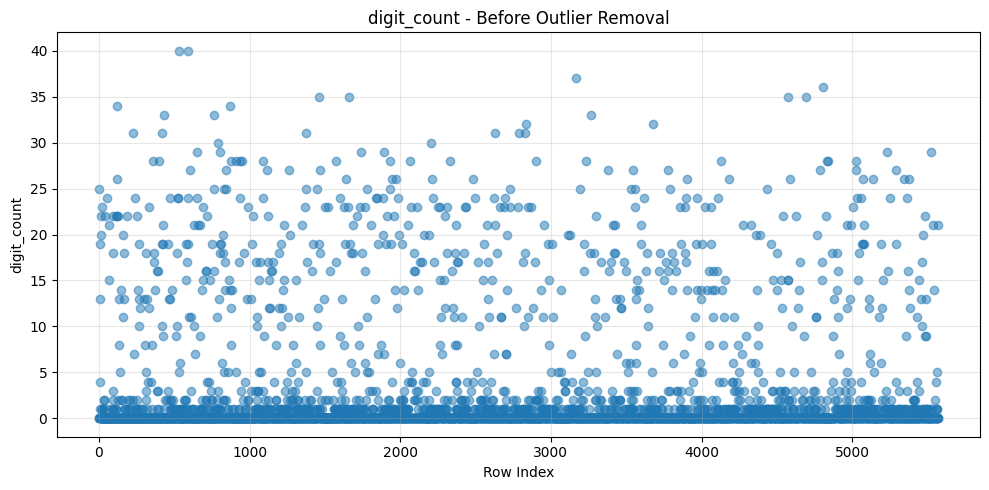

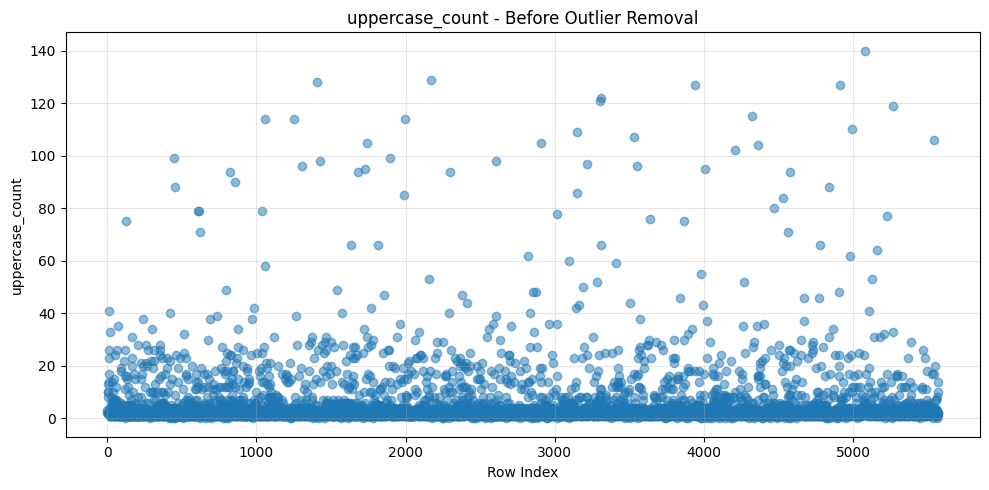

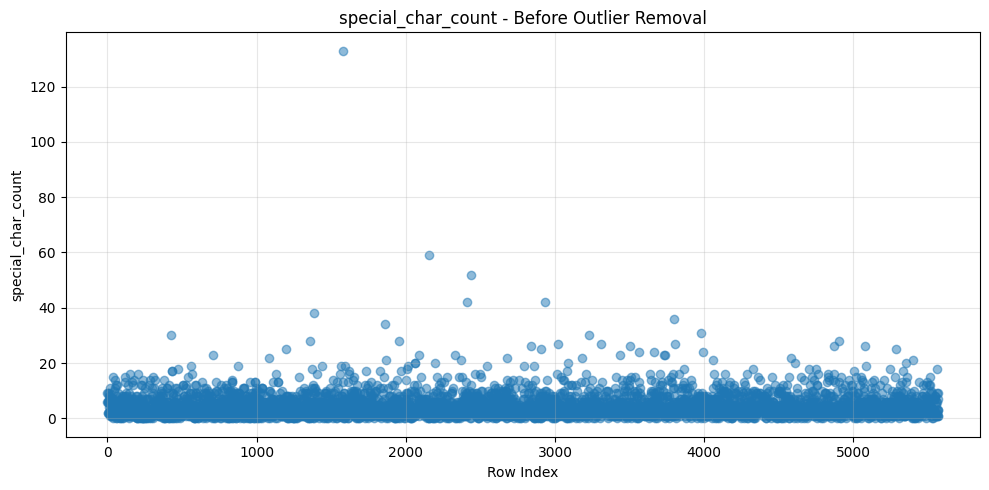

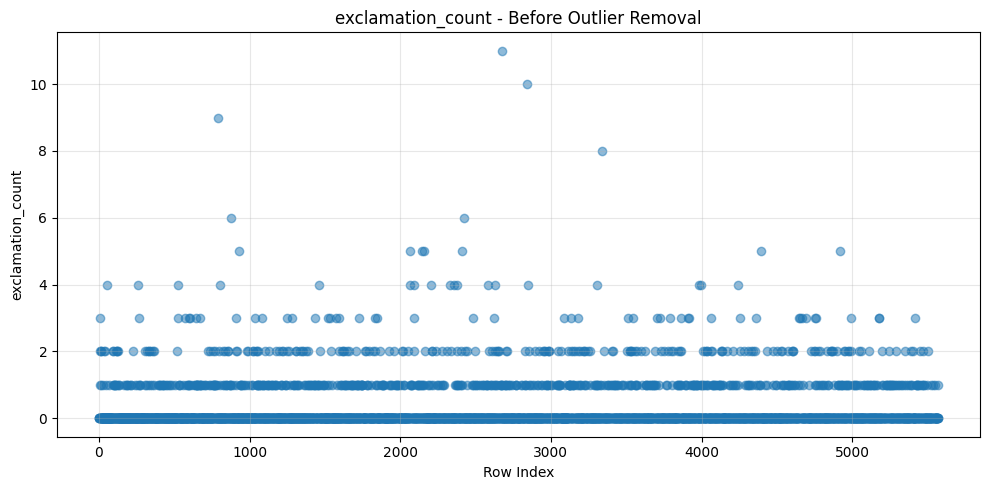

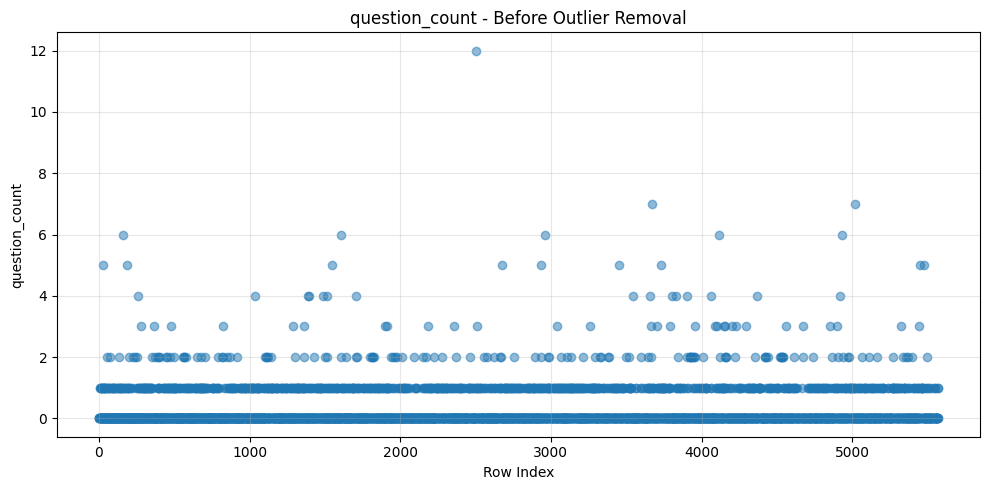

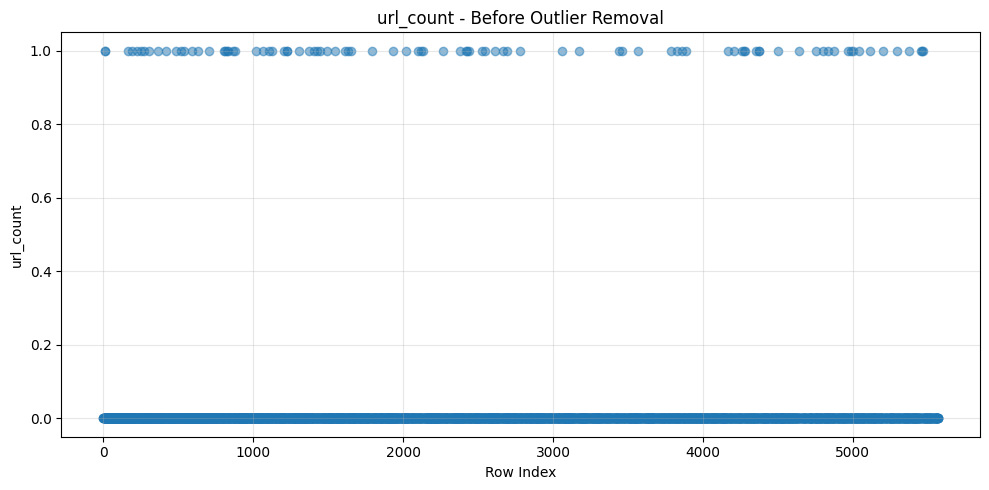

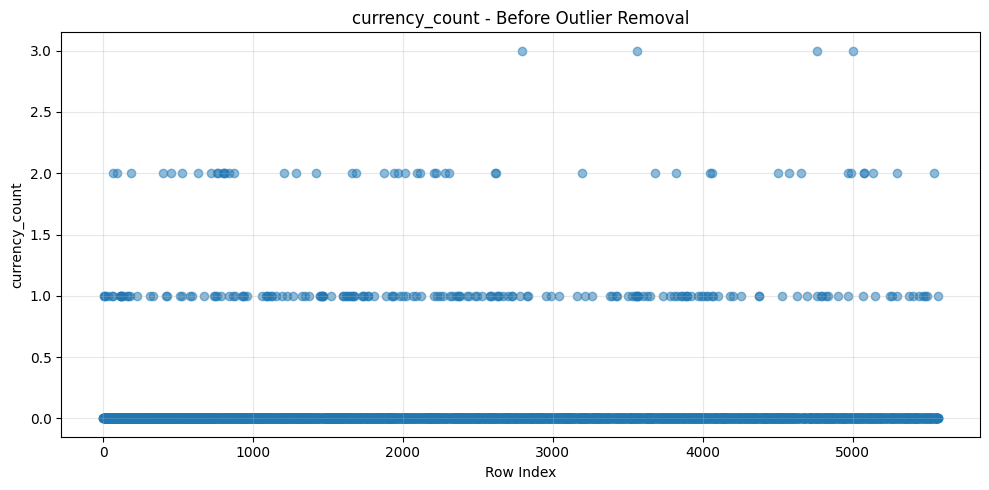

In [14]:
import matplotlib.pyplot as plt

for feature in numeric_features:
    plt.figure(figsize=(10, 5))

    plt.scatter(df.index, df[feature], alpha=0.5)

    plt.title(f"{feature} - Before Outlier Removal")
    plt.xlabel("Row Index")
    plt.ylabel(feature)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

REMOVAL OF OUTLIERS


In [15]:
from scipy.stats import zscore

# Numerical features
numeric_features = [
    "message_length",
    "word_count",
    "digit_count",
    "uppercase_count",
    "special_char_count",
    "exclamation_count",
    "question_count",
    "url_count",
    "currency_count"
]


z_scores = df[numeric_features].apply(zscore)
outliers = (z_scores.abs() > 3)
row_outliers = outliers.any(axis=1)
df_clean = df[~row_outliers].copy()


print("Original dataset size:", df.shape)
print("New dataset size:", df_clean.shape)


removed_rows = len(df) - len(df_clean)

print("Number of rows removed:", removed_rows)
# Count outliers for each numerical feature
outlier_counts = outliers.sum()

print("Outliers in each feature:")
print(outlier_counts)

Original dataset size: (4434, 10)
New dataset size: (3826, 10)
Number of rows removed: 608
Outliers in each feature:
message_length         53
word_count             52
digit_count           184
uppercase_count        78
special_char_count     57
exclamation_count      79
question_count         62
url_count              90
currency_count        224
dtype: int64


VISUALIZATION OF OUTLIERS

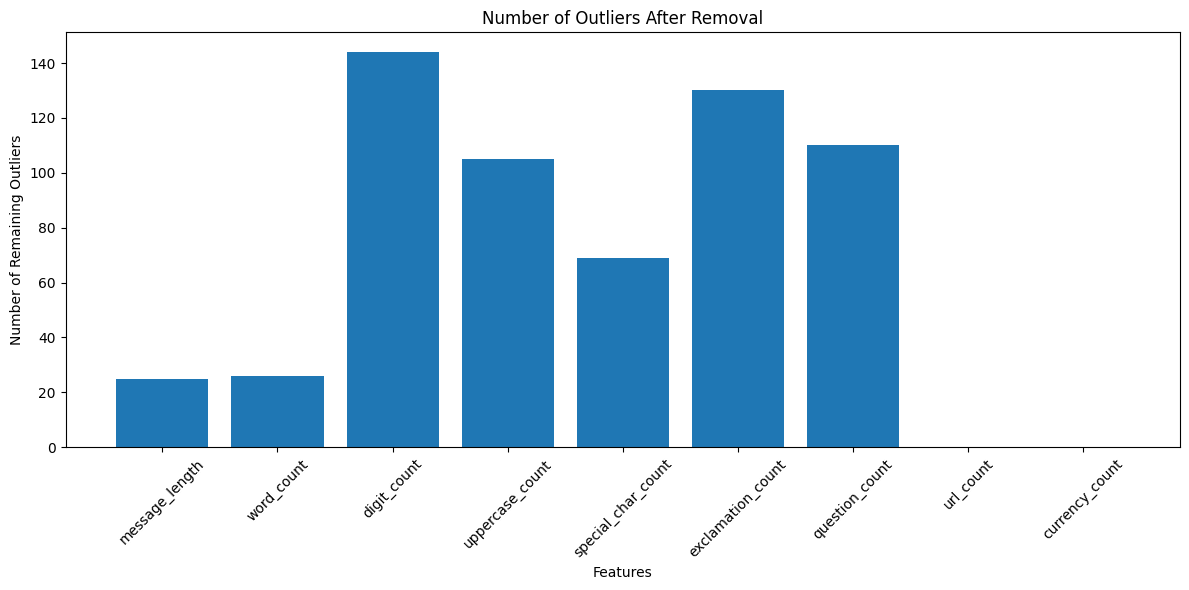

In [16]:
from scipy.stats import zscore
import matplotlib.pyplot as plt

# Calculate Z-scores again AFTER outlier removal
z_scores_after = df_clean[numeric_features].apply(zscore)

# Detect any remaining outliers
outliers_after = (z_scores_after.abs() > 3)

# Count remaining outliers for each feature
outlier_counts_after = outliers_after.sum().values

# Create graph
plt.figure(figsize=(12, 6))

plt.bar(
    numeric_features,
    outlier_counts_after
)

plt.title("Number of Outliers After Removal")
plt.xlabel("Features")
plt.ylabel("Number of Remaining Outliers")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

SCATTER PLOT AFTER REMOVAL

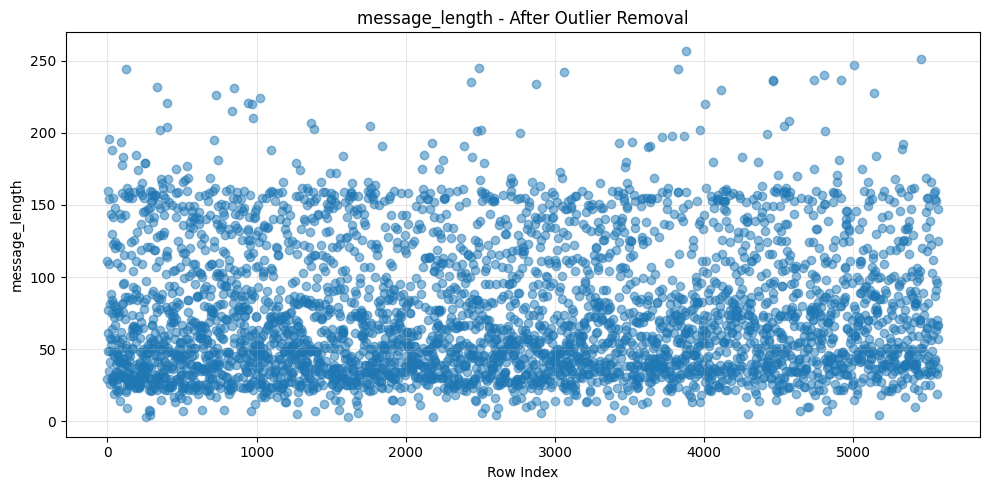

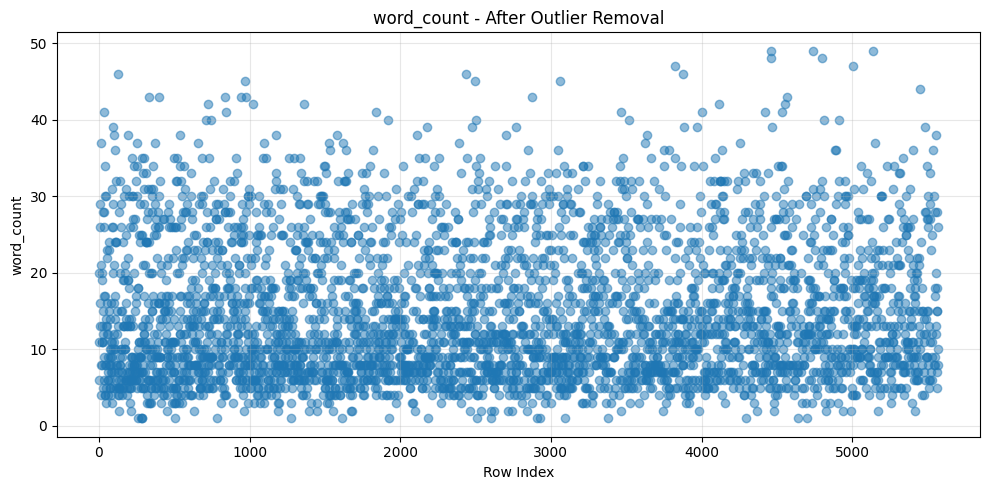

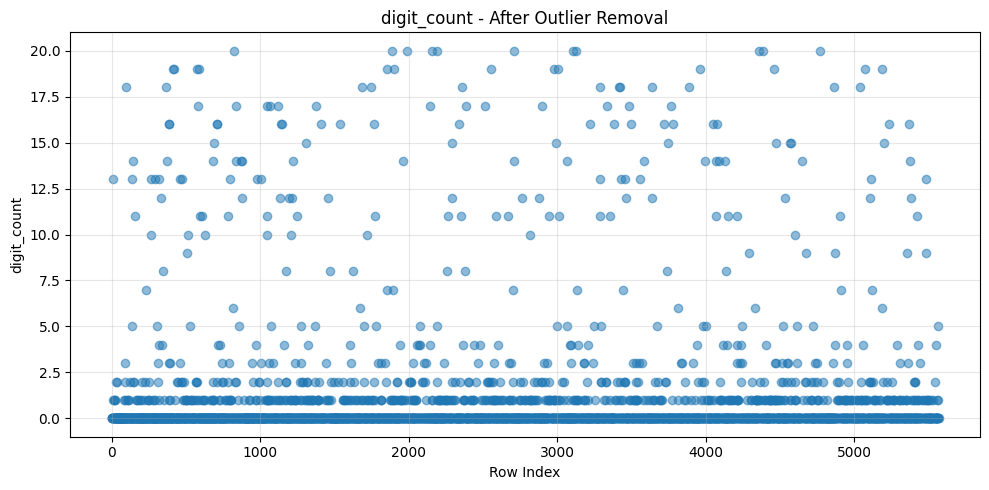

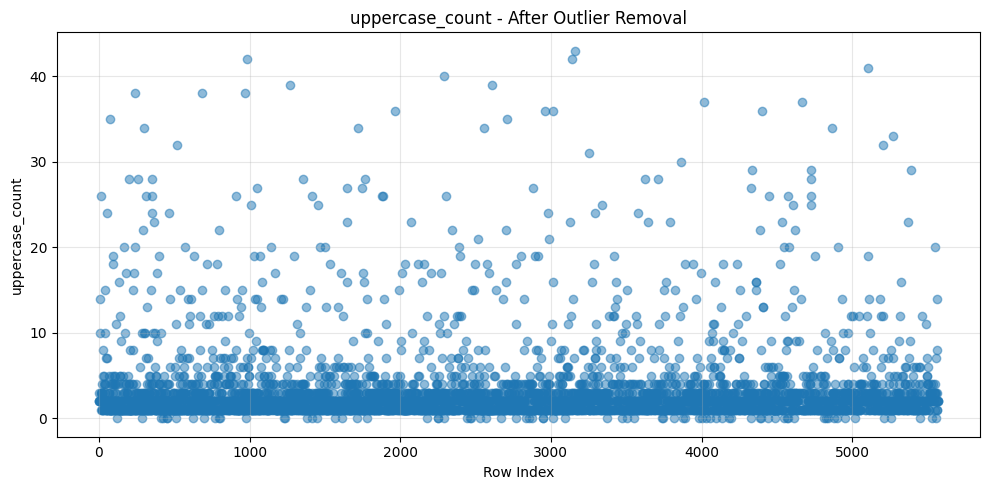

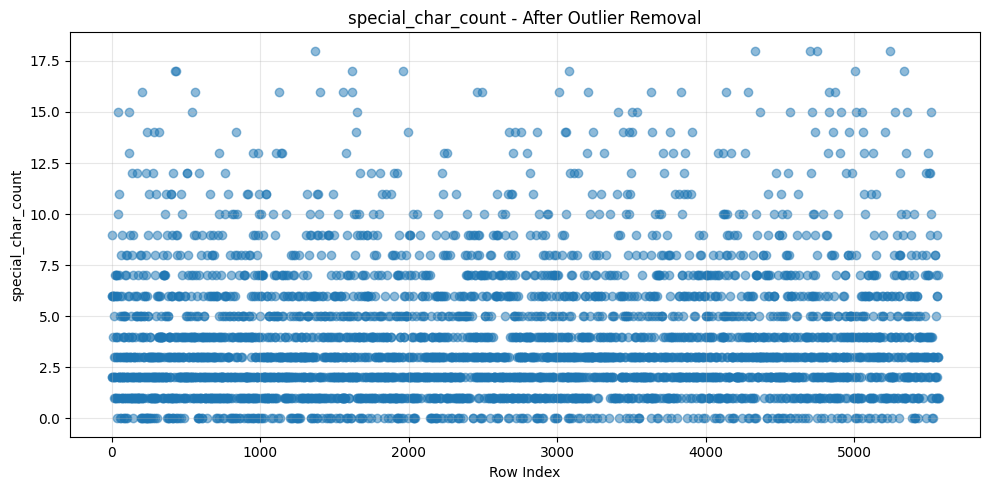

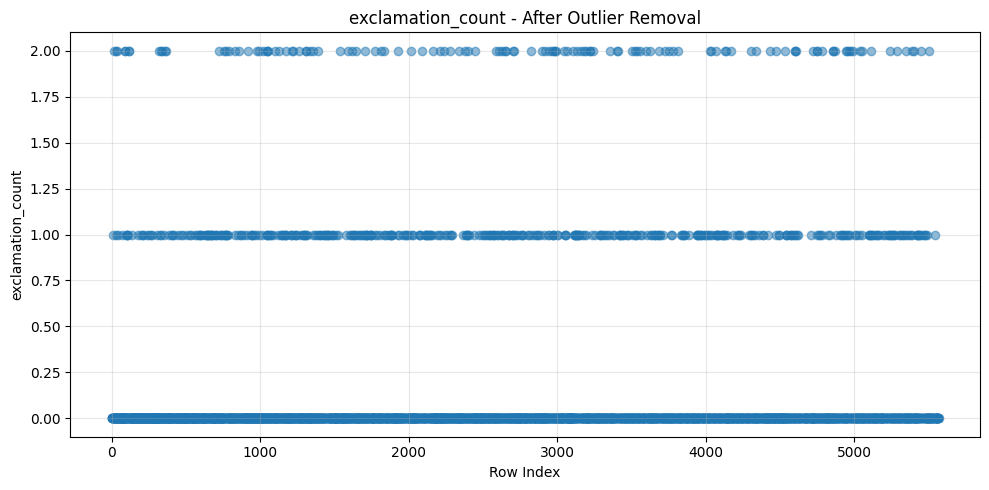

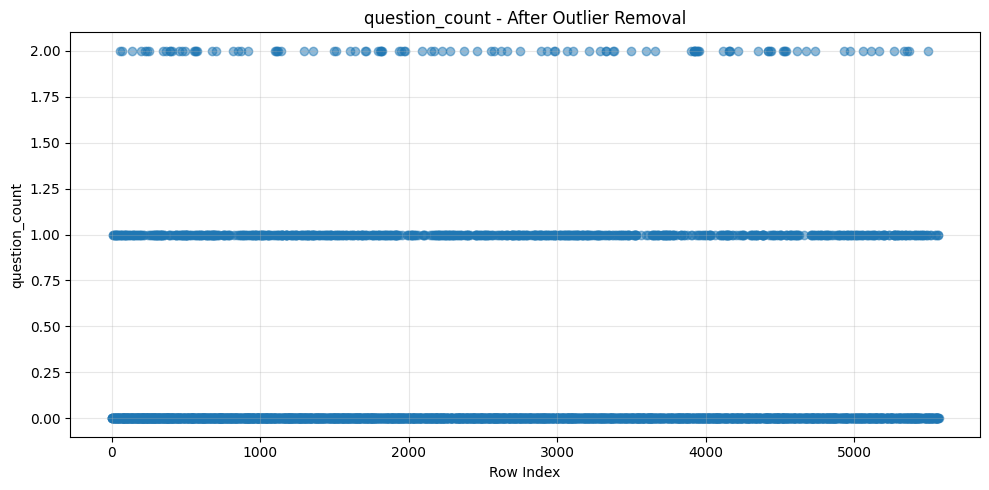

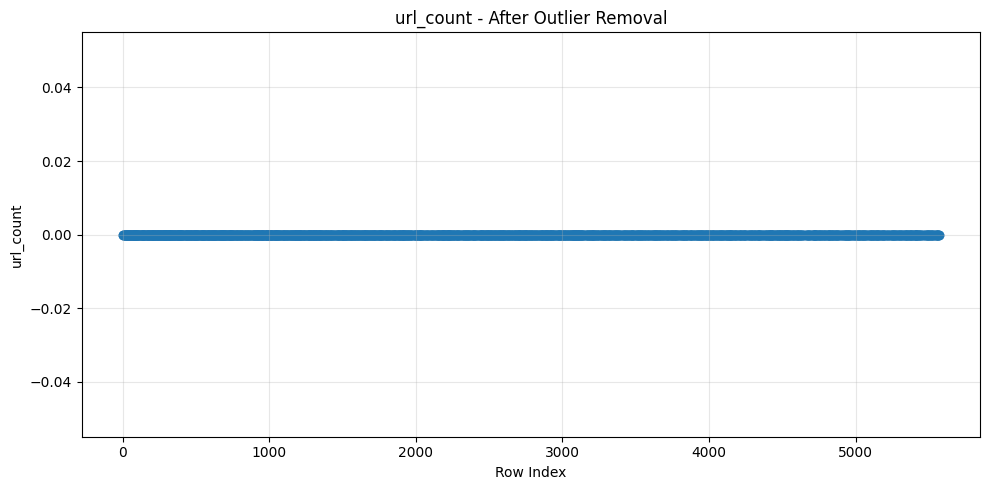

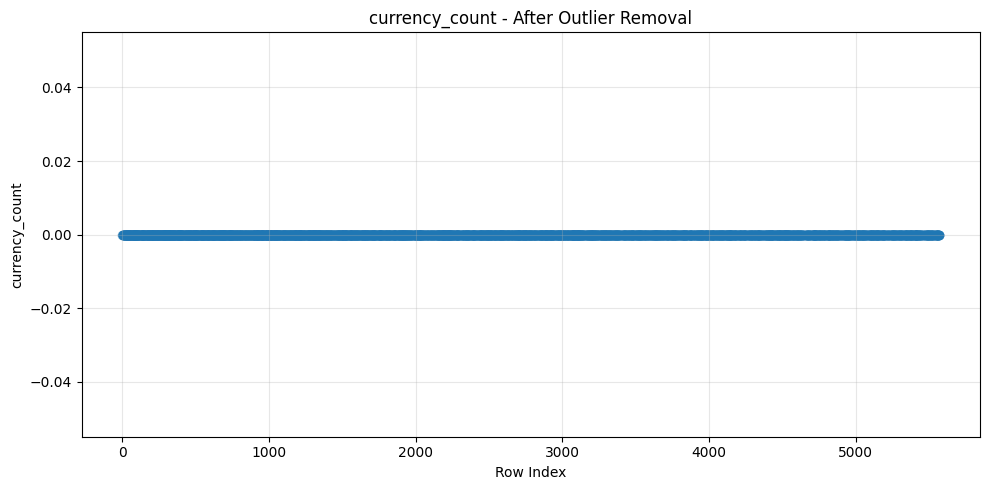

In [17]:
for feature in numeric_features:
    plt.figure(figsize=(10, 5))

    plt.scatter(
        df_clean.index,
        df_clean[feature],
        alpha=0.5
    )

    plt.title(f"{feature} - After Outlier Removal")
    plt.xlabel("Row Index")
    plt.ylabel(feature)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

CLASSIFICATION MODELS

REQUIRED LIBRARIES


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = [
    "message_length",
    "word_count",
    "digit_count",
    "uppercase_count",
    "special_char_count",
    "exclamation_count",
    "question_count",
    "url_count",
    "currency_count"
]

X = df[numeric_features]
y = df["spam"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4434, 9)
Target shape: (4434,)


TEST TRAIN DATA

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 3547
Testing samples : 887


**SVM**

SVM TRAINING

In [21]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", random_state=42))
])

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM model training completed successfully.")

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, zero_division=0)
svm_recall = recall_score(y_test, y_pred_svm, zero_division=0)
svm_f1 = f1_score(y_test, y_pred_svm, zero_division=0)

print("       SVM PERFORMANCE")
print(f"Accuracy  : {svm_accuracy:.4f}")
print(f"Precision : {svm_precision:.4f}")
print(f"Recall    : {svm_recall:.4f}")
print(f"F1 Score  : {svm_f1:.4f}")

SVM model training completed successfully.
       SVM PERFORMANCE
Accuracy  : 0.9865
Precision : 0.9828
Recall    : 0.9194
F1 Score  : 0.9500


SVM VISULIZATION

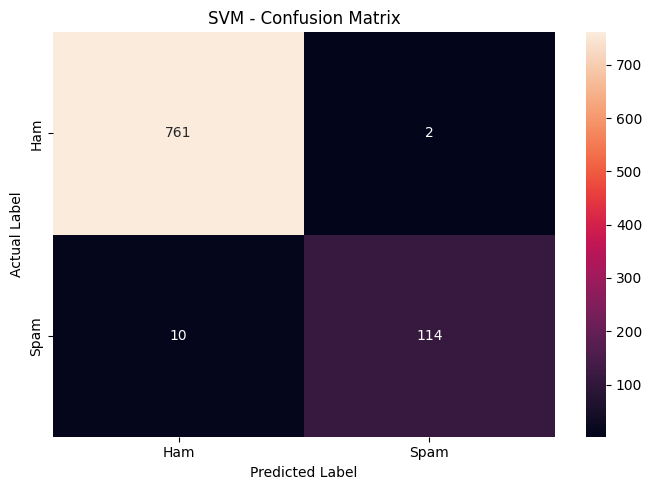

In [22]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

**NAIVE** **BAYES**

Naive Bayes Training

In [23]:
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train, y_train)

# Make predictions
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes model training completed successfully.")
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, zero_division=0)
nb_recall = recall_score(y_test, y_pred_nb, zero_division=0)
nb_f1 = f1_score(y_test, y_pred_nb, zero_division=0)

print("     NAIVE BAYES PERFORMANCE")
print(f"Accuracy  : {nb_accuracy:.4f}")
print(f"Precision : {nb_precision:.4f}")
print(f"Recall    : {nb_recall:.4f}")
print(f"F1 Score  : {nb_f1:.4f}")

Naive Bayes model training completed successfully.
     NAIVE BAYES PERFORMANCE
Accuracy  : 0.9718
Precision : 0.9024
Recall    : 0.8952
F1 Score  : 0.8988


NAIVE BAYES VISULIZATION

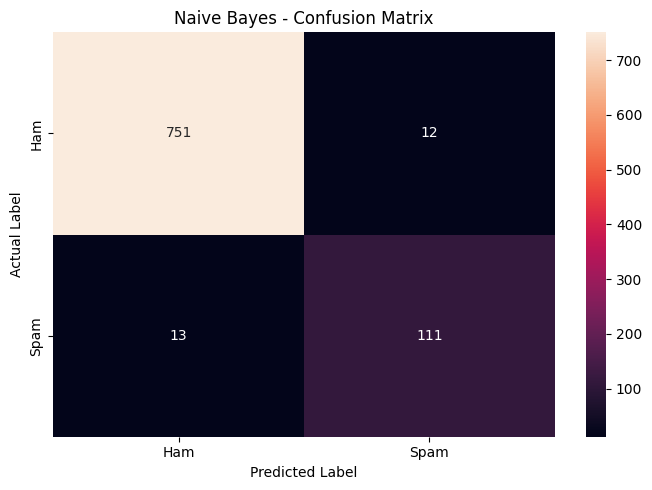

In [24]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

**DECISION TREE**

Decision Tree Training

In [26]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree model training completed successfully.")
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, zero_division=0)
dt_recall = recall_score(y_test, y_pred_dt, zero_division=0)
dt_f1 = f1_score(y_test, y_pred_dt, zero_division=0)

print("      DECISION TREE PERFORMANCE")
print(f"Accuracy  : {dt_accuracy:.4f}")
print(f"Precision : {dt_precision:.4f}")
print(f"Recall    : {dt_recall:.4f}")
print(f"F1 Score  : {dt_f1:.4f}")

Decision Tree model training completed successfully.
      DECISION TREE PERFORMANCE
Accuracy  : 0.9696
Precision : 0.8819
Recall    : 0.9032
F1 Score  : 0.8924


DECISION TREE VISUALIZATION

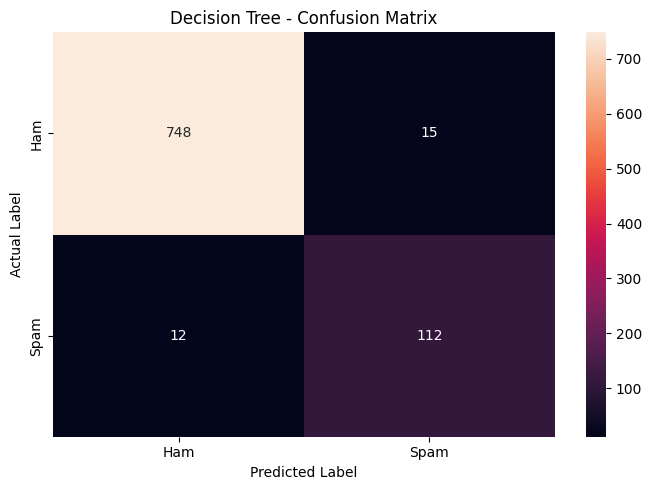

In [27]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()